In [1]:
import pandas as pd
import matplotlib.pyplot as plot
import seaborn as sns

In [2]:
df = pd.read_csv("4) house Prediction Data Set.csv")
df.head()

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...


In [10]:
print(df.shape)

(506, 1)


In [11]:
print(df.head(2))

                                                   0
0   0.00632  18.00   2.310  0  0.5380  6.5750  65...
1   0.02731   0.00   7.070  0  0.4690  6.4210  78...


In [12]:
df = pd.read_csv(
    "4) house Prediction Data Set.csv",
    sep=r'\s+',
    header=None
)

print(df.shape)
df.head()

(506, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [13]:
df.columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B',
    'LSTAT', 'MEDV'
]

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [14]:
X = df[['RM']]
y = df['MEDV']

print(X.head())
print(y.head())

      RM
0  6.575
1  6.421
2  7.185
3  6.998
4  7.147
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (404, 1)
Testing data: (102, 1)


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [17]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[23.73238293 26.92950201 19.68456842 20.45112913 22.61993506 22.45166563
 19.03953562 21.47009399 21.98425056 20.09589368]


In [18]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 46.144775347317264
R-squared: 0.3707569232254778


In [19]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 9.348301406497722
Intercept: -36.24631889813792


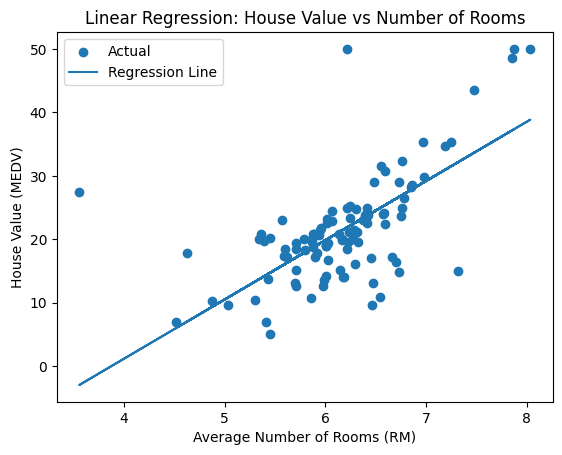

In [21]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Regression Line")

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Value (MEDV)")
plt.title("Linear Regression: House Value vs Number of Rooms")
plt.legend()
plt.savefig("linear_regression_graph.png",dpi=300,bbox_inches="tight")
plt.show()